### Model Pipeline

1. Raw table_data (string)

        ↓ linearize

2. Linearized text (string)

        ↓ tokenizer.encode()

3. Token IDs (integers)

        ↓ model's embedding layer (learned lookup table, inside the model)

4. Token embeddings + positional embeddings

        ↓ encoder self-attention layers (bidirectional)

5. Encoder hidden states (contextualized representations, one vector per input token)

        ↓ fed into every decoder layer via cross-attention

6. Decoder (causal self-attention + cross-attention into step 5)

        ↓ generates one token at a time, autoregressively

7. Output logits → softmax → generated token

        ↓ repeat step 6-7 until <eos>
        
8. Decoded text = generated financial commentary

execution order:

1. Setup and preprocessing  
2. Shared datasets and evaluation utilities  
3. Zero-shot T5-small baseline  
4. Fine-tuned T5-small  
5. Combined model-level metrics and prediction-level outputs  

### Installs and Imports

In [1]:
!pip install -q  -U transformers
!pip install -q -U datasets
!pip install -q -U evaluate
!pip install -q tokenizers
!pip install rouge_score


In [2]:
!pip install rouge_score
!pip install sacrebleu
!pip install meteor-score
!pip install bert-score


ERROR: Could not find a version that satisfies the requirement meteor-score (from versions: none)
ERROR: No matching distribution found for meteor-score


In [3]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import torch

In [4]:
from datasets import Dataset, DatasetDict
import evaluate

In [5]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)

In [6]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [8]:
print("PyTorch version:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Using preprocessing notebook to use the same variables and features.

In [10]:
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/266/266_final_project"
PREPROCESSING_SCRIPT = os.path.join(BASE_DIR, "train_splitEDA.py")

# This script creates train_df, test_df, summarize_market_table, and token_length.
%run -i "$PREPROCESSING_SCRIPT"

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

KeyboardInterrupt: 

NameError: name 'train_df' is not defined

In [ ]:
# %%capture
# %run -i "/content/drive/MyDrive/Colab Notebooks/266/266_final_project/train_splitEDA.py"

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (7823 > 512). Running this sequence through the model will result in indexing errors


In [ ]:
# after = set(globals().keys())
# new_vars = after - before
# #variables from exported notebook above
# print(new_vars)

{'summarize_market_table', 'sample', 'parsed', 'token_length', 'test_file', 'linearize_table', 'before', 'test_df', 'build_encoder_input', 'sample_df', 'model_name', 'tokenizer', 'train_file', 'summary', '__file__', 'i', '_i9', 'train_df', 'save_dir', 'linearize_table_compact', 'StringIO', '_i8'}


### Build Encoder input and decoder targets
- Encoder processes the structured financial data withfull context, no generation order needed.
- Decoder generates text token by token
- Cross-attention lets the decoder ground each generated word back in the specific numbers/facts from the encoder. This will be helpful to check the factual consistency of hypothesis.
- Bidirectional encoder:The encoder will use full, non-causal self-attention. It needs the full self attention to see the entire table at once to build a complete representation.
- So, no masking the tokens on the input side.
- Decoder: The decoder will use causal masked self-attention since it generates autoregressively and can't peek at future output tokens.
- Models to use : **T5/ BART**

## Prevent Data Leakage
In my previous version, metric_for_best_model="eval_loss" means the Trainer picked the "best" epoch checkpoint using cross-entropy loss on the test set, and EarlyStoppingCallback stopped training based on that same signal. It did not optimize directly on reported ROUGE/BLEU/BERTScore as these were computed after the fact, but the **checkpoint selection itself saw test data**

Fixing the leakage below, by carving out a validation set

In [11]:
# Carve a validation set out of train_df.
# test_df stays fully untouched until final eval
val_fraction = 0.15  # last 15% of each market's train dates  validation

train_parts, val_parts = [], []

for market, group in train_df.groupby("market"):
    unique_dates = sorted(group["date"].unique())
    split_idx = int(len(unique_dates) * (1 - val_fraction))
    train_dates = unique_dates[:split_idx]
    val_dates = unique_dates[split_idx:]

    train_parts.append(group[group["date"].isin(train_dates)])
    val_parts.append(group[group["date"].isin(val_dates)])

train_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size (unchanged):", len(test_df))

# Sanity check — same leak check pattern you used for train/test
for market in train_df["market"].unique():
    tr_max = train_df[train_df["market"] == market]["date"].max()
    va_min = val_df[val_df["market"] == market]["date"].min()
    print(f"{market:15s} train_max={tr_max.date()}  val_min={va_min.date()}  leak={tr_max >= va_min}")

Train size: 2627
Val size: 516
Test size (unchanged): 795
cattle          train_max=2022-09-14  val_min=2022-09-15  leak=False
corn            train_max=2022-05-25  val_min=2022-05-26  leak=False
currency        train_max=2022-01-13  val_min=2022-01-14  leak=False
dairy           train_max=2022-09-13  val_min=2022-09-14  leak=False
equity market   train_max=2022-03-25  val_min=2022-03-28  leak=False
gold            train_max=2021-03-31  val_min=2021-04-01  leak=False
lean hog        train_max=2022-09-14  val_min=2022-09-15  leak=False
oil             train_max=2021-11-10  val_min=2021-11-11  leak=False
soybean         train_max=2022-05-25  val_min=2022-05-26  leak=False
treasury        train_max=2022-03-23  val_min=2022-03-25  leak=False
wheat           train_max=2022-05-25  val_min=2022-05-26  leak=False


In [12]:
def build_encoder_input(row):
    return (
        "Generate a financial market report.\n\n"
        f"Instruction:\n"
        f"{row['instruction']}\n\n"
        f"Market summary:\n"
        f"{row['market_summary']}"
    )

In [13]:
for df in (train_df, test_df):
    df["market_summary"] = df["table_data"].apply(summarize_market_table)
    df["encoder_input"] = df.apply(build_encoder_input, axis=1)
    df["decoder_target"] = df["report"]

print(train_df[["encoder_input", "decoder_target"]].head(2))

                                       encoder_input  \
0  Generate a financial market report.\n\nInstruc...   
1  Generate a financial market report.\n\nInstruc...   

                                      decoder_target  
0  Cattle futures posted moderate to strong gains...  
1  Cattle prices are trying to turn higher, as th...  


Building encoder input for val_df too

In [14]:
val_df["market_summary"] = val_df["table_data"].apply(summarize_market_table)
val_df["encoder_input"] = val_df.apply(build_encoder_input, axis=1)
val_df["decoder_target"] = val_df["report"]

In [13]:
# Inspect lengths before choosing truncation limits.
train_df["input_length"] = train_df["encoder_input"].apply(token_length)
train_df["target_length"] = train_df["decoder_target"].apply(token_length)

print("Input lengths")
display(train_df["input_length"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

print("\nTarget lengths")
display(train_df["target_length"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

print("\nTargets longer than 384 tokens:", (train_df["target_length"] > 384).sum())
print("Percentage longer than 384:", (train_df["target_length"] > 384).mean())

Input lengths


,input_length
count,3143.000000
mean,174.361120
std,6.731297
min,148.000000
50%,176.000000
75%,178.000000
90%,181.000000
95%,183.000000
99%,185.000000
max,188.000000



Target lengths


,target_length
count,3143.000000
mean,131.379574
std,86.968900
min,6.000000
50%,113.000000
75%,169.500000
90%,257.000000
95%,320.900000
99%,393.000000
max,560.000000



Targets longer than 384 tokens: 42
Percentage longer than 384: 0.013363028953229399


In [14]:
print("Targets > 128:",(train_df["target_length"] > 128).mean())
print("Targets > 256:",(train_df["target_length"] > 256).mean())

Targets > 128: 0.42666242443525293
Targets > 256: 0.10054088450524976


In [15]:
print("ENCODER INPUT\n")
print(train_df.iloc[0]["encoder_input"])

print("\n")
print("DECODER TARGET\n")
print(train_df.iloc[0]["decoder_target"])

ENCODER INPUT

Generate a financial market report.

Instruction:
Please act as an expert financial market analyst. Please generate a market report:
1. by analyzing the historical market data provided.
2. following the market report example provided.

Market summary:
Product: Live Cattle Future (front month) (December)
Symbol: LEZ1
Period start: 2021-11-02
Period end: 2021-12-02
Trading days: 132
Starting close: 129.95
Ending close: 170.90
Period high: 171.00
Period low: 128.88
Absolute price change: 40.95
Percentage price change: 31.51%
Daily return volatility: 1.25%
Maximum daily gain: 10.11%
Maximum daily loss: -4.69%
Average volume: 9696
Maximum volume: 31903
Minimum volume: 558
Overall price trend: Upward


DECODER TARGET

Cattle futures posted moderate to strong gains as cash trade stayed supportive in the live cattle market. Dec live cattle gained 1.650 to 137.650, and Feb cattle were .975 higher to 139.575. Feeders saw mixed, to mostly higher market as Jan feeders were slightly 

In [16]:
print("Targets > 384:",(train_df["target_length"] > 384).sum())
print("Percentage > 384:",(train_df["target_length"] > 384).mean())

Targets > 384: 42
Percentage > 384: 0.013363028953229399


### Shared configuration and Hugging Face datasets

### Model
1. Fine-tuned pretrained T5-small - Load T5 model : "t5-small"  - Chunk long sequences. Split long documents into 512‑token chunks and process them sequentially.
2. t5 base
2. t5_tokenizer = AutoTokenizer.from_pretrained("google-t5/t5-large")
3. t5_model = AutoModelForSeq2SeqLM.from_pretrained("google-t5/t5-large")
4. LongT5 (4k–16k tokens) - not possible due to cost constraints

#### Convert Pandas DataFrames into Hugging Face datasets

wrap train_df/test_df in a HuggingFace Dataset, apply tokenize_batch, and fine-tune with Seq2SeqTrainer

Dataset + Seq2SeqTrainer training loop

In [15]:
MODEL_NAME = "google-t5/t5-small"
MAX_INPUT_LENGTH = 256
MAX_TARGET_LENGTH = 384
GENERATION_KWARGS = {
    "max_new_tokens": MAX_TARGET_LENGTH,
    "num_beams": 4,
    "early_stopping": True,}

In [16]:
MODEL_DIRS = {
    "zero_shot": os.path.join(BASE_DIR, "models", "t5-small-zero-shot"),
    "finetuned": os.path.join(BASE_DIR, "models", "t5-small-finetuned"),
    }
for path in MODEL_DIRS.values():
    os.makedirs(path, exist_ok=True)

In [17]:
# Create huggingface datasets
train_dataset = Dataset.from_pandas(
    train_df[["encoder_input", "decoder_target"]],preserve_index=False,)

val_dataset = Dataset.from_pandas(
    val_df[["encoder_input", "decoder_target"]], preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["encoder_input", "decoder_target"]],preserve_index=False,)

test_inputs = test_df["encoder_input"].tolist()
references = test_df["decoder_target"].tolist()

val_inputs = val_df["encoder_input"].tolist()
val_references = val_df["decoder_target"].tolist()

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['encoder_input', 'decoder_target'],
    num_rows: 2627
})
Dataset({
    features: ['encoder_input', 'decoder_target'],
    num_rows: 516
})
Dataset({
    features: ['encoder_input', 'decoder_target'],
    num_rows: 795
})


### Shared batched prediction function

In [18]:
def generate_predictions_batched(model,tokenizer,texts,batch_size=8,
                                 max_input_length=MAX_INPUT_LENGTH,generation_kwargs=None,):

    """Generate predictions in batches for zero shot or fine tuned seq2seq models"""

    if generation_kwargs is None:
        generation_kwargs = GENERATION_KWARGS

    model = model.to(DEVICE)
    model.eval()
    predictions = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        encoded = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_input_length,
        )
        encoded = {key: value.to(DEVICE) for key, value in encoded.items()}

        with torch.no_grad():
            generated_ids = model.generate(**encoded, **generation_kwargs,)

        batch_predictions = tokenizer.batch_decode(
            generated_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True,
        )
        predictions.extend(batch_predictions)

    return predictions

### Shared eval metrics  function

In [29]:
rouge_metric = evaluate.load("rouge")
sacrebleu_metric = evaluate.load("sacrebleu")
meteor_metric = evaluate.load("meteor")
bertscore_metric = evaluate.load("bertscore")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [28]:
def evaluate_predictions(predictions, references, model_label):
    """Return one flat dictionary suitable for a model-level results DataFrame."""
    rouge_scores = rouge_metric.compute(
        predictions=predictions,
        references=references,
        use_stemmer=True,)

    bleu_scores = sacrebleu_metric.compute(
        predictions=predictions,
        references=[[reference] for reference in references],)

    meteor_scores = meteor_metric.compute(
        predictions=predictions,
        references=references,)

    bert_scores = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="en",)

    return {
        "model": model_label,
        "rouge1": rouge_scores["rouge1"],
        "rouge2": rouge_scores["rouge2"],
        "rougeL": rouge_scores["rougeL"],
        "sacrebleu": bleu_scores["score"],
        "meteor": meteor_scores["meteor"],
        "bertscore_precision": float(np.mean(bert_scores["precision"])),
        "bertscore_recall": float(np.mean(bert_scores["recall"])),
        "bertscore_f1": float(np.mean(bert_scores["f1"])),
    }

In [21]:
# Every model will append 1 metrics row and 1 prediction set
metrics_rows = []
prediction_frames = []

### T5 zero-shot baseline:
running the pretrained, non-fine-tuned T5-small on test set before comparing it to fine-tuned version.

1. Load pretrained tokenizer and model  
2. Generate batched predictions directly from raw test strings  
3. Evaluate predictions  
4. Append metrics and predictions to shared DataFrames  

A data collator is not required for zero-shot generation because there is no Trainer or training batch.

### Tokenize
Apply to both train and test datasets : We can see input_ids, attention_mask, labels

Run again when loading from checkpoint, because tokenized datasets are not saved automatically.

Do not run the zero shot predictions again, as they dont have data leakage. They are run without training

In [ ]:
# load the zero-shot model
zero_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
zero_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

print("Loaded zero-shot model:", MODEL_NAME)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loaded zero-shot model: google-t5/t5-small


In [ ]:
# Run this once to save the zero-shot model
zero_model.save_pretrained(MODEL_DIRS["zero_shot"])
zero_tokenizer.save_pretrained(MODEL_DIRS["zero_shot"])
print("Saved zero-shot checkpoint to:", MODEL_DIRS["zero_shot"])

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved zero-shot checkpoint to: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/models/t5-small-zero-shot


### Generate zero-shot predictions

In [ ]:
zero_predictions = generate_predictions_batched(
    model=zero_model,
    tokenizer=zero_tokenizer,
    texts=test_inputs,
    batch_size=8,
)

print("Generated predictions:", len(zero_predictions))
print("\nExample prediction:\n", zero_predictions[0])
print("\nReference:\n", references[0])

Generated predictions: 795

Example prediction:
 : 36.77 Percentage price change: 25.63% Daily return volatility: 1.37% Maximum daily gain: 13.01% Maximum daily loss: -2.85% Average volume: 8873 Maximum volume: 35921 Minimum volume: 510 Overall price trend: Upward

Reference:
 Oct live cattle gained 0.075 to 151.675, closing with a new contract high for the seventh straight day, and Dec slipped 0.825 to 153.300. Feeders were mostly lower with the exception of the front month with expiration on the 27th. Nov feeders traded 1.225 lower to 177.925. December cattle posted a new contract high early in the session, before turning lower on the day. This could be a sign of consolidation, or a loss of momentum after a strong rally. Cash trade was still undeveloped on Tuesday, but expectations are for cash trade to trend higher week over week. Southern asking prices are $152, with undefined bids. Beef retail values have jumped in the last two days. At midday Tuesday, Choice carcasses traded 3.95

## Evaluate and collect zero-shot results

In [ ]:
zero_metrics = evaluate_predictions(
    predictions=zero_predictions,
    references=references,
    model_label="t5-small-zero-shot",
)
metrics_rows.append(zero_metrics)

zero_output_df = test_df.copy()
zero_output_df["model"] = "t5-small-zero-shot"
zero_output_df["prediction"] = zero_predictions
prediction_frames.append(
    zero_output_df[["model", "encoder_input", "decoder_target", "prediction"]]
)

display(pd.DataFrame([zero_metrics]))

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1
0,t5-small-zero-shot,0.057857,0.001057,0.040656,0.00402,0.026264,0.771497,0.780427,0.775841


In [ ]:
# Free GPU memory before loading the training model.
del zero_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# Fine-tuned T5-small

Order:

1. Load a fresh tokenizer and pretrained model  
2. Tokenize train and test datasets  
3. Create the dynamic data collator  
4. Define training arguments and Trainer  
5. Train and save the model  
6. Generate batched predictions using the saved/best model  
7. Evaluate and append results

WE're not using padding="max_length" to ensure that padded label tokens dont contribute to the loss. The data collator will dynamically pad each batch.

The tokenizer, data collator, and model are included in the same fine-tuning pipeline.

In [22]:
# Loading a fresh model and tokenizer for fine-tuning

ft_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
ft_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print("Loaded fresh model for fine-tuning:", MODEL_NAME)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded fresh model for fine-tuning: google-t5/t5-small


### Tokenize train and test datasets

In [23]:
def tokenize_batch(examples):
    model_inputs = ft_tokenizer(
        examples["encoder_input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,)

    labels = ft_tokenizer(
        text_target=examples["decoder_target"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [24]:
# Tokenize train, test, val

tokenized_train = train_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=train_dataset.column_names,)

tokenized_val = val_dataset.map(
    tokenize_batch, batched=True,
    remove_columns=val_dataset.column_names,)

tokenized_test = test_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=test_dataset.column_names,)

print(tokenized_train)
print(tokenized_val)
print(tokenized_test)
print(tokenized_train[0].keys())

Map:   0%|          | 0/2627 [00:00<?, ? examples/s]

Map:   0%|          | 0/516 [00:00<?, ? examples/s]

Map:   0%|          | 0/795 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2627
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 516
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 795
})
dict_keys(['input_ids', 'attention_mask', 'labels'])


### Create the data collator
Instead of manually padding every example to max_input_length, data collater will handle the padding dynamically per batch

In [25]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=ft_tokenizer,
    model=ft_model,
    padding="longest",
    label_pad_token_id=-100,)

print(data_collator)

DataCollatorForSeq2Seq(tokenizer=T5Tokenizer(name_or_path='google-t5/t5-small', vocab_size=32100, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32000: AddedToken("<extra_id_99>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32001: AddedToken("<extra_id_98>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32002: AddedToken("<extra_id_97>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32003: AddedToken("<extra_id_96>", rstrip=False, lstrip=False, singl

### Training arguments and Trainer


In [ ]:
# # from transformers import Seq2SeqTrainingArguments
# #  loaded from check point -do not run again

# training_args = Seq2SeqTrainingArguments(
#     output_dir="./t5-small-financial-commentary",

#     eval_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=5e-5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     weight_decay=0.01,
#     num_train_epochs=5,
#     predict_with_generate=True,
#     logging_steps=50,
#     save_total_limit=2,
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     greater_is_better=False,
#     fp16=True, # for T4 GPU
#     report_to="none"
# )

In [26]:
training_args = Seq2SeqTrainingArguments(
    output_dir=os.path.join(BASE_DIR, "checkpoints", "t5-small-finetuning"),
    learning_rate=3e-4,
    lr_scheduler_type="linear",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=4,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

Create the trainer

In [27]:
trainer = Seq2SeqTrainer(
    model=ft_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val, # changed to validation set
    processing_class=ft_tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],)

print("Trainer created")

Trainer created


In [28]:
print(type(tokenized_train))
print(type(tokenized_test))

<class 'datasets.arrow_dataset.Dataset'>
<class 'datasets.arrow_dataset.Dataset'>


### Model Training

In [29]:
#  run once, load from check point -do not run again
train_result = trainer.train()

Epoch,Training Loss,Validation Loss
1,3.620937,3.352561
2,3.365715,3.179780
3,3.236010,3.092083
4,3.063595,3.037372
5,2.962629,2.997050
6,2.953362,2.981326
7,2.910353,2.955295
8,2.862132,2.941660
9,2.832325,2.936361
10,2.820591,2.936038


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


In [30]:
display(pd.DataFrame([train_result.metrics]))

,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,epoch
0,594.9054,44.158,5.53,1.259818e+15,3.108753,10.0


### Save fine tuned model

In [31]:
trainer.save_model(MODEL_DIRS["finetuned"])
ft_tokenizer.save_pretrained(MODEL_DIRS["finetuned"])

with open(
    os.path.join(MODEL_DIRS["finetuned"], "training_metrics.json"),
    "w",
) as file:
    json.dump(train_result.metrics, file, indent=2)

print("Saved fine-tuned model to:", MODEL_DIRS["finetuned"])

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/models/t5-small-finetuned


In [ ]:
# load from checkpoint in a later session

# ft_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIRS["finetuned"])
# ft_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_DIRS["finetuned"]).to(DEVICE)

# print("Loaded fine-tuned checkpoint.")

### Generate fine-tuned Validation predictions in batches

In [35]:
val_inputs = val_df["encoder_input"].tolist()
val_references = val_df["decoder_target"].tolist()

In [36]:
fine_tuned_model = trainer.model.to(DEVICE)

In [37]:
val_predictions = generate_predictions_batched(
    model=fine_tuned_model,
    tokenizer=ft_tokenizer,
    texts=val_inputs,
    batch_size=8,
)

print("Generated validation predictions:", len(val_predictions))
print("\nExample prediction:\n", val_predictions[0])
print("\nReference:\n", val_references[0])

Generated validation predictions: 516

Example prediction:
 Live cattle futures saw mixed trade on Tuesday, as the cash market pushed through the 200-day moving average. Oct live cattle gained 0.425 to 142.750, and Oct live cattle gained 0.425 to 148.750. Feeders saw mixed trade as Oct feeders gained 0.425 to 148.750. For the week, Oct feeders were 0.425 higher, and Oct feeders were 0.425 higher. For the week, Oct live cattle were 0.425 higher, and Oct feeders were softer on the week. Cash trade has been trending higher, as the market looks to be looking for direction.

Reference:
 Live cattle futures found some buying strength on Thursday as the cash market trade ticked higher this week, while feeders treaded mixed held in check by technical selling and high grain prices. Oct cattle slipped 1.275 to 145.625 and Dec cattle traded 1.275 higher to 151.325. October feeders traded .500 lower to 108.925. October and December live cattle futures held support levels early in the session and d

### Training/validation-loss plot

In [55]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head())

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,5.105715,1.415891,0.000298,0.060790,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.369094,1.549656,0.000296,0.121581,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.236437,0.948186,0.000295,0.182371,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.114163,0.837159,0.000293,0.243161,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.971455,1.335606,0.000291,0.303951,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
train_loss_df = (history_df[history_df["loss"].notna()& history_df["epoch"].notna()][["epoch", "loss"]])

val_loss_df = (history_df[history_df["eval_loss"].notna()& history_df["epoch"].notna()][["epoch", "eval_loss"]])

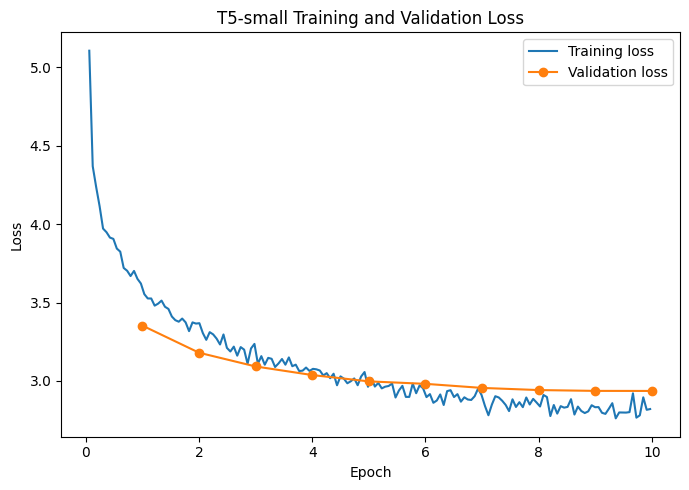

Saved: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_small_training_validation_loss.png


In [57]:
plt.figure(figsize=(7, 5))

plt.plot(train_loss_df["epoch"],
    train_loss_df["loss"],
    label="Training loss",
         )
plt.plot(
    val_loss_df["epoch"],
    val_loss_df["eval_loss"],
    marker="o",
    label="Validation loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("T5-small Training and Validation Loss")
plt.legend()
plt.tight_layout()

loss_plot_path = os.path.join(BASE_DIR,"t5_small_training_validation_loss.png")
plt.savefig(loss_plot_path,dpi=300,bbox_inches="tight",)
plt.show()

print("Saved:", loss_plot_path)

## Sentence-BERT for STS evaluation

In [32]:
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import os
import json

sts_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [31]:
def compute_sts_scores(predictions, references, batch_size=32):
    """
    Compute Sentence-BERT cosine similarity between each
    generated prediction and its reference commentary.
    """
    pred_embeddings = sts_model.encode(
        predictions,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    ref_embeddings = sts_model.encode(
        references,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )

    # Because embeddings are normalized,
    # dot product = cosine similarity
    scores = np.sum(pred_embeddings * ref_embeddings, axis=1)

    return scores, float(np.mean(scores))

### Existing evaluation function needs to be extended

In [27]:
def evaluate_predictions_full(predictions,references,model_label,):
    """
    Existing lexical/semantic metrics + Sentence-BERT STS.
    """

    metrics = evaluate_predictions(
        predictions=predictions,
        references=references,
        model_label=model_label,
    )
    sts_scores, sts_mean = compute_sts_scores(
        predictions=predictions,
        references=references,
    )
    metrics["sts_sbert_cosine"] = sts_mean

    return metrics, sts_scores

### Evaluate validation predictions

In [41]:
# T5-small validation evaluation

val_metrics, val_sts_scores = evaluate_predictions_full(
    predictions=val_predictions,
    references=val_references,
    model_label="t5-small-finetuned-validation",
)
display(pd.DataFrame([val_metrics]))

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine
0,t5-small-finetuned-validation,0.26609,0.095224,0.199882,6.09714,0.172506,0.877784,0.841133,0.858718,0.623755


In [42]:
# save results to directory
val_output_df = val_df.copy()

val_output_df["model"] = "t5-small-finetuned"
val_output_df["prediction"] = val_predictions
val_output_df["sts_sbert_cosine"] = val_sts_scores

val_path = os.path.join(BASE_DIR,"t5_small_validation_predictions.csv")
val_output_df.to_csv(val_path, index=False)
print("Saved validation predictions:", val_path)

Saved validation predictions: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_small_validation_predictions.csv


## FINAL T5-small test predictions

In [43]:
# FINAL HELD-OUT TEST SET
test_inputs = test_df["encoder_input"].tolist()
test_references = test_df["decoder_target"].tolist()

print("Test examples:", len(test_inputs))

Test examples: 795


### Generate Test predictions

In [44]:
fine_tuned_predictions = generate_predictions_batched(
    model=fine_tuned_model,
    tokenizer=ft_tokenizer,
    texts=test_inputs,
    batch_size=8,
)

print("Generated test predictions:", len(fine_tuned_predictions))
print("\nExample prediction:\n")
print(fine_tuned_predictions[0])
print("\nReference:\n")
print(test_references[0])

Generated test predictions: 795

Example prediction:

Oct live cattle slipped 0.300 to 142.250, and Oct cattle slipped 0.250 to 143.250. Feeders saw mixed trade as Oct feeders gained 0.250 to 143.250. Oct feeders were 0.250 lower to 143.250. For the week, Oct live cattle were 0.025 higher, and Oct feeders were 0.025 higher. For the week, Oct feeders were 0.025 higher, and Oct feeders were 0.025 higher. For the week, Oct feeders were softer on the week. The cash market is still in an uptrend for the week. The cash market is still trading at a strong premium to the cash market. The cash market is still in an uptrend, but the market is looking for a near-term low.

Reference:

Oct live cattle gained 0.075 to 151.675, closing with a new contract high for the seventh straight day, and Dec slipped 0.825 to 153.300. Feeders were mostly lower with the exception of the front month with expiration on the 27th. Nov feeders traded 1.225 lower to 177.925. December cattle posted a new contract high 

### Final test evaluation

In [45]:
fine_tuned_metrics, test_sts_scores = evaluate_predictions_full(
    predictions=fine_tuned_predictions,
    references=test_references,
    model_label="t5-small-finetuned",)

display(pd.DataFrame([fine_tuned_metrics]))

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine
0,t5-small-finetuned,0.258826,0.086809,0.190723,5.489256,0.161707,0.875445,0.8374,0.855727,0.635853


In [46]:
# save predictions
t5_small_test_df = test_df.copy()

t5_small_test_df["model"] = "t5-small-finetuned"
t5_small_test_df["prediction"] = fine_tuned_predictions
t5_small_test_df["sts_sbert_cosine"] = test_sts_scores

t5_small_predictions_path = os.path.join(BASE_DIR,"t5_small_finetuned_test_predictions.csv")
t5_small_test_df.to_csv(t5_small_predictions_path,index=False,)
print("Saved T5-small test predictions:",t5_small_predictions_path)

Saved T5-small test predictions: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_small_finetuned_test_predictions.csv


In [47]:
t5_small_metrics_df = pd.DataFrame([fine_tuned_metrics])
t5_small_metrics_path = os.path.join(BASE_DIR,"t5_small_finetuned_metrics.csv")
t5_small_metrics_df.to_csv(t5_small_metrics_path,index=False,)
print("Saved:", t5_small_metrics_path)

Saved: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_small_finetuned_metrics.csv


## Post-hoc 5-fold stability analysis
Technically its not true K-fold cross-validation
Using the predictions I've already generated.

To assess the stability of test-set performance, we partitioned held-out predictions into five randomly assigned folds and recomputed evaluation metrics for each subset. We report the mean and standard deviation across folds. Because models were not retrained separately for each fold, this analysis measures metric stability rather than conventional K-fold cross-validation.

In [48]:
from sklearn.model_selection import KFold

K = 5
kf = KFold(n_splits=K,shuffle=True,random_state=SEED,)
fold_metrics = []

test_indices = np.arange(len(test_df))

for fold_num, (_, fold_idx) in enumerate(kf.split(test_indices),start=1,):

    # predictions and references that belong to this fold
    fold_preds = [fine_tuned_predictions[i]for i in fold_idx]
    fold_refs = [test_references[i]for i in fold_idx]

    fold_metrics_row, _ = evaluate_predictions_full(
        predictions=fold_preds,
        references=fold_refs,
        model_label=f"t5-small-finetuned-fold{fold_num}",)

    fold_metrics_row["fold"] = fold_num
    fold_metrics_row["n_examples"] = len(fold_idx)
    fold_metrics.append(fold_metrics_row)

fold_metrics_df = pd.DataFrame(fold_metrics)

display(fold_metrics_df)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine,fold,n_examples
0,t5-small-finetuned-fold1,0.277876,0.096550,0.202562,6.293273,0.171575,0.878992,0.840469,0.859037,0.657810,1,159
1,t5-small-finetuned-fold2,0.257201,0.089146,0.190437,5.300662,0.163747,0.875666,0.836586,0.855402,0.631220,2,159
2,t5-small-finetuned-fold3,0.253741,0.081379,0.186662,5.279566,0.162492,0.871538,0.835276,0.852766,0.606644,3,159
3,t5-small-finetuned-fold4,0.251101,0.082582,0.187261,5.240479,0.149342,0.874044,0.836429,0.854540,0.628514,4,159
4,t5-small-finetuned-fold5,0.254083,0.084608,0.186469,5.250250,0.161381,0.876987,0.838239,0.856888,0.655076,5,159


### Aggregate mean and standard deviation:

In [49]:
metric_columns = [col for col in fold_metrics_df.columns if col not in ["model", "fold", "n_examples"]]

fold_aggregate_df = (fold_metrics_df[metric_columns] .agg(["mean", "std"]).T.reset_index())

fold_aggregate_df.columns = ["metric","mean","std",]

display(fold_aggregate_df)

,metric,mean,std
0,rouge1,0.258800,0.010881
1,rouge2,0.086853,0.006175
2,rougeL,0.190678,0.006834
3,sacrebleu,5.472846,0.459252
4,meteor,0.161707,0.007987
5,bertscore_precision,0.875445,0.002839
6,bertscore_recall,0.837400,0.002015
7,bertscore_f1,0.855727,0.002376
8,sts_sbert_cosine,0.635853,0.021095


### save all

In [50]:
fold_metrics_path = os.path.join(BASE_DIR,"t5_small_5fold_stability_metrics.csv")

fold_aggregate_path = os.path.join(BASE_DIR,"t5_small_5fold_stability_aggregate.csv")

fold_metrics_df.to_csv(fold_metrics_path,index=False,)

fold_aggregate_df.to_csv(fold_aggregate_path,index=False,)

print("Saved fold metrics:", fold_metrics_path)
print("Saved aggregate metrics:", fold_aggregate_path)

Saved fold metrics: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_small_5fold_stability_metrics.csv
Saved aggregate metrics: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_small_5fold_stability_aggregate.csv


### Bootstrap 95% CI for STS

It gives an uncertainity measure, easy to compute, since we already have the per example STS scores

In [51]:
def bootstrap_mean_ci(scores,n_bootstrap=2000,confidence=0.95,seed=SEED,):
    rng = np.random.default_rng(seed)
    scores = np.asarray(scores)
    bootstrap_means = []

    for _ in range(n_bootstrap):
        sample = rng.choice(
            scores,
            size=len(scores),
            replace=True,)
        bootstrap_means.append(sample.mean())

    alpha = 1 - confidence
    lower = np.percentile(bootstrap_means,100 * alpha / 2,)
    upper = np.percentile(bootstrap_means,100 * (1 - alpha / 2),)

    return {
        "mean": float(scores.mean()),
        "ci_lower": float(lower),
        "ci_upper": float(upper),
    }

sts_ci = bootstrap_mean_ci(test_sts_scores)
print(sts_ci)

{'mean': 0.6358527541160583, 'ci_lower': 0.6235178709030151, 'ci_upper': 0.6483650207519531}


### Numerical-grounding diagnostic

Financial factuality/numeracy is central to our hypothesis, so this is good to add. This metric asks:

When the generated commentary states a number, can that number be found in the model's structured input?


Numeric support rate, an auxiliary diagnostic measuring the proportion of numeric values in generated text that approximately match values available in the model input.

In [52]:
import re

def extract_numbers(text):
    """
    Extract signed integers/decimals from text.
    """
    if text is None:
        return []

    pattern = r"[-+]?\d*\.?\d+"
    values = []

    for match in re.findall(pattern, str(text)):
        try:
            values.append(float(match))
        except ValueError:
            pass

    return values

def numeric_support_rate(prediction,source_text,rel_tol=0.01,abs_tol=0.05,):
    """
    Fraction of numeric values generated in the prediction that occur in the model input.
    """
    pred_nums = extract_numbers(prediction)
    source_nums = extract_numbers(source_text)

    if len(pred_nums) == 0:
        return np.nan

    supported = 0

    for pred_num in pred_nums:
        match_found = False
        for source_num in source_nums:
            tolerance = max(abs_tol,rel_tol * max(abs(pred_num),abs(source_num),),)
            if abs(pred_num - source_num) <= tolerance:
                match_found = True
                break

        if match_found:
            supported += 1

    return supported / len(pred_nums)

In [53]:
t5_small_test_df["numeric_support_rate"] = [numeric_support_rate(prediction=pred,source_text=source,)
    for pred, source in zip(
        t5_small_test_df["prediction"],
        t5_small_test_df["encoder_input"],
    )]
numeric_mean = (t5_small_test_df["numeric_support_rate"].dropna().mean())

print("Mean numeric support rate:",numeric_mean)

print("Examples containing generated numbers:",t5_small_test_df["numeric_support_rate"].notna().sum())

Mean numeric support rate: 0.42066427621796937
Examples containing generated numbers: 686


In [54]:
t5_small_test_df.to_csv(t5_small_predictions_path,index=False,)

In [ ]:
metrics_df = pd.DataFrame(metrics_rows)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

display(metrics_df)
display(predictions_df.head())

metrics_path = os.path.join(BASE_DIR, "model_metrics.csv")
predictions_path = os.path.join(BASE_DIR, "model_predictions.csv")

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)

print("Saved model metrics to:", metrics_path)
print("Saved predictions to:", predictions_path)

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1
0,t5-small-zero-shot,0.057857,0.001057,0.040656,0.004020,0.026264,0.771497,0.780427,0.775841
1,t5-small-finetuned,0.272943,0.096536,0.203133,6.403039,0.177760,0.876687,0.840908,0.858156


,model,encoder_input,decoder_target,prediction
0,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,"Oct live cattle gained 0.075 to 151.675, closi...",: 36.77 Percentage price change: 25.63% Daily ...
1,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,Oct live cattle slipped .225 to 151.450 with e...,": 37.77 Percentage price change: 26,32% Daily ..."
2,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,"The cattle market came under selling pressure,...",: 142.72 Absolute price change: 36.88 Percenta...
3,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,"The cattle market was choppy on Friday, finish...",": 37.33 Percentage price change: 26,10% Daily ..."
4,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,October live cattle went off the board today a...,: 179.45 Period high: 182.38 Period low: 146.7...


## T5-base Model

In [58]:
# Free memory from T5-small before loading T5-base
del ft_model, trainer
torch.cuda.empty_cache() if torch.cuda.is_available() else None

### Model name and directory

In [59]:
MODEL_NAME = "google-t5/t5-base"

In [ ]:
# Shared configs are same as t5-small
# MAX_INPUT_LENGTH = 256
# MAX_TARGET_LENGTH = 384
# GENERATION_KWARGS = {
#     "max_new_tokens": MAX_TARGET_LENGTH,
#     "num_beams": 4,
#     "early_stopping": True,
# }

MODEL_DIRS = {
    "zero_shot": os.path.join(BASE_DIR, "models", "t5-base-zero-shot"),
    "finetuned": os.path.join(BASE_DIR, "models", "t5-base-finetuned"),
}

1. Need to change batch_size to 4 instead of 8 for T4 GPU memory management. T5-base is 3 times more parameters than T5-small (220M vs. 60M), so it needs more VRAM per example during both training and generation.

2. Also will add gradient_accumulation_steps=2 in Seq2SeqTrainingArguments so the effective batch size, which drives the gradient update, stays at 8, and that will match the t5-small.

### Load T5-base model and zero shot it

In [ ]:
zero_tokenizer_base = AutoTokenizer.from_pretrained("google-t5/t5-base")
zero_model_base = AutoModelForSeq2SeqLM.from_pretrained("google-t5/t5-base").to(DEVICE)
print("Loaded zero-shot model:", MODEL_NAME)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded zero-shot model: google-t5/t5-base


In [ ]:
# save the zero-t5-base model locally, run once.

zero_model_base.save_pretrained(MODEL_DIRS["zero_shot"])
zero_tokenizer_base.save_pretrained(MODEL_DIRS["zero_shot"])
print("Saved zero-shot base checkpoint to:", MODEL_DIRS["zero_shot"])

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved zero-shot base checkpoint to: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/models/t5-base-zero-shot


### generate zero-shot base predictions

In [ ]:
zero_pred_base = generate_predictions_batched(
    model=zero_model_base,
    tokenizer=zero_tokenizer_base,
    texts=test_inputs,
    batch_size=4,)

print("Generated predictions:", len(zero_pred_base))
print("\nExample prediction:\n", zero_pred_base[0])
print("\nReference:\n", references[0])

Generated predictions: 795

Example prediction:
 142.72 Period high: 182.38 Period low: 142.72 Period high: 182.38 Period low: 142.72 Absolute price change: 36.77 Percentage price change: 25.63% Daily return volatility: 1.37% Maximum daily gain: 13.01% Maximum daily loss: -2.85% Average volume: 8873 Maximum volume: 35921 Minimum volume: 510 Average volume: 8873 Maximum volume: 8873 Minimum volume: 35921 Minimum volume: 510 Average volume:

Reference:
 Oct live cattle gained 0.075 to 151.675, closing with a new contract high for the seventh straight day, and Dec slipped 0.825 to 153.300. Feeders were mostly lower with the exception of the front month with expiration on the 27th. Nov feeders traded 1.225 lower to 177.925. December cattle posted a new contract high early in the session, before turning lower on the day. This could be a sign of consolidation, or a loss of momentum after a strong rally. Cash trade was still undeveloped on Tuesday, but expectations are for cash trade to trend

### Evaluate zero_model_base and append results

In [ ]:
zero_metrics_base = evaluate_predictions(
    predictions=zero_pred_base,
    references=references,
    model_label="t5-base-zero-shot",
)
metrics_rows.append(zero_metrics_base)

zero_output_df_base = test_df.copy()
zero_output_df_base["model"] = "t5-base-zero-shot"
zero_output_df_base["prediction"] = zero_pred_base
prediction_frames.append(
    zero_output_df_base[["model", "encoder_input", "decoder_target", "prediction"]]
)

display(pd.DataFrame([zero_metrics_base]))

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1
0,t5-base-zero-shot,0.057949,0.003745,0.040108,0.224147,0.032917,0.752887,0.77749,0.764631


## Fine-tuned T5-base

In [61]:
# free memory before fine-tuning
# del zero_model_base
torch.cuda.empty_cache() if torch.cuda.is_available() else None

In [62]:
# load fresh model and tokenizer

ft_tokenizer_base = AutoTokenizer.from_pretrained(MODEL_NAME)
ft_model_base = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print("Loaded fresh model for fine-tuning:", MODEL_NAME)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded fresh model for fine-tuning: google-t5/t5-base


### Tokenize train and test datasets

In [63]:
# T5-base tokenization: TRAIN / VALIDATION / TEST

def tokenize_batch_base(examples):
    model_inputs = ft_tokenizer_base(
        examples["encoder_input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
    )
    labels = ft_tokenizer_base(
        text_target=examples["decoder_target"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [64]:
tokenized_train_base = train_dataset.map(
    tokenize_batch_base,
    batched=True,
    remove_columns=train_dataset.column_names,
)
tokenized_val_base = val_dataset.map(
    tokenize_batch_base,
    batched=True,
    remove_columns=val_dataset.column_names,
)
tokenized_test_base = test_dataset.map(
    tokenize_batch_base,
    batched=True,
    remove_columns=test_dataset.column_names,
)
print(tokenized_train_base)
print(tokenized_val_base)
print(tokenized_test_base)

Map:   0%|          | 0/2627 [00:00<?, ? examples/s]

Map:   0%|          | 0/516 [00:00<?, ? examples/s]

Map:   0%|          | 0/795 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2627
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 516
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 795
})


In [65]:
# data collator
data_collator_base = DataCollatorForSeq2Seq(
    tokenizer=ft_tokenizer_base,
    model=ft_model_base,
    padding="longest",
    label_pad_token_id=-100,
)
print(data_collator_base)

DataCollatorForSeq2Seq(tokenizer=T5Tokenizer(name_or_path='google-t5/t5-base', vocab_size=32100, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32000: AddedToken("<extra_id_99>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32001: AddedToken("<extra_id_98>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32002: AddedToken("<extra_id_97>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32003: AddedToken("<extra_id_96>", rstrip

### Training args with smaller batch size

keeping all args same as t5-small, except batch_size and adding gradient_accumulation_steps=2, to keep the training set-up comparable between the two models.

Note: learning rate is same as t5-small for a controlled  comparision. However, T5-base can sometimes be less tolerant of high learning rates. After the first epoch if training and validation loss become unstable or produces nans or validation performance worsens, I'll rerun with lower learning rate 1e-4.



In [66]:
training_args = Seq2SeqTrainingArguments(
    output_dir=os.path.join(BASE_DIR, "checkpoints", "t5-base-finetuning"),
    learning_rate=3e-4,
    lr_scheduler_type="linear",
    num_train_epochs=10,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2, # effective batch size = 4 * 2 = 8, same as T5-small

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=4,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

### Create Trainer

In [67]:
trainer_base = Seq2SeqTrainer(
    model=ft_model_base,
    args=training_args,
    train_dataset=tokenized_train_base,
    eval_dataset=tokenized_val_base,
    processing_class=ft_tokenizer_base,
    data_collator=data_collator_base,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
print("T5-base Trainer created")

T5-base Trainer created


In [68]:
train_result_base = trainer_base.train()

Epoch,Training Loss,Validation Loss
1,7.748675,3.468419
2,7.767755,3.419414
3,7.744347,3.419271
4,7.702472,3.419180
5,8.124041,3.419353
6,7.779649,3.419327


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


In [69]:
display(pd.DataFrame([train_result_base.metrics]))

,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,epoch
0,1168.3214,22.485,2.816,3.370030e+15,7.731811,6.0


In [70]:
#  save finetuned model

trainer_base.save_model(MODEL_DIRS["finetuned"])

ft_tokenizer_base.save_pretrained(MODEL_DIRS["finetuned"])

with open(os.path.join(MODEL_DIRS["finetuned"],"training_metrics.json",),"w",) as file:

    json.dump(train_result_base.metrics,file,indent=2,)

print("Saved fine-tuned T5-base:",MODEL_DIRS["finetuned"],)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned T5-base: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/models/t5-small-finetuned


In [71]:
print(ft_model_base.config.model_type)
print(ft_model_base.config.d_model)

t5
768


In [42]:
# load checkpoint in a later session
metrics_path = os.path.join(
    model_dir,
    "training_metrics.json"
)

with open(metrics_path, "r") as f:
    saved_training_metrics = json.load(f)

print(saved_training_metrics)

{'train_runtime': 1168.3214, 'train_samples_per_second': 22.485, 'train_steps_per_second': 2.816, 'total_flos': 3370030056161280.0, 'train_loss': 7.731810835477912, 'epoch': 6.0}


In [44]:
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/266/266_final_project"

print("BASE_DIR:", BASE_DIR)

BASE_DIR: /content/drive/MyDrive/Colab Notebooks/266/266_final_project


In [45]:
trainer_state_files = []

for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        if file == "trainer_state.json":
            full_path = os.path.join(root, file)
            trainer_state_files.append(full_path)

print("Found trainer_state.json files:\n")

for path in trainer_state_files:
    print(path)

Found trainer_state.json files:

/content/drive/MyDrive/Colab Notebooks/266/266_final_project/checkpoints/t5-small-finetuning/checkpoint-2961/trainer_state.json
/content/drive/MyDrive/Colab Notebooks/266/266_final_project/checkpoints/t5-small-finetuning/checkpoint-3290/trainer_state.json
/content/drive/MyDrive/Colab Notebooks/266/266_final_project/checkpoints/t5-base-finetuning/checkpoint-1974/trainer_state.json
/content/drive/MyDrive/Colab Notebooks/266/266_final_project/checkpoints/t5-base-finetuning/checkpoint-1316/trainer_state.json


In [46]:
trainer_state_files = []

for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        if file == "trainer_state.json":
            full_path = os.path.join(root, file)
            trainer_state_files.append(full_path)

print("Found trainer_state.json files:\n")

for path in trainer_state_files:
    print(path)

Found trainer_state.json files:

/content/drive/MyDrive/Colab Notebooks/266/266_final_project/checkpoints/t5-small-finetuning/checkpoint-2961/trainer_state.json
/content/drive/MyDrive/Colab Notebooks/266/266_final_project/checkpoints/t5-small-finetuning/checkpoint-3290/trainer_state.json
/content/drive/MyDrive/Colab Notebooks/266/266_final_project/checkpoints/t5-base-finetuning/checkpoint-1974/trainer_state.json
/content/drive/MyDrive/Colab Notebooks/266/266_final_project/checkpoints/t5-base-finetuning/checkpoint-1316/trainer_state.json


In [61]:
latest_trainer_state_path = trainer_state_files[2]

print("Using:")
print(latest_trainer_state_path)

Using:
/content/drive/MyDrive/Colab Notebooks/266/266_final_project/checkpoints/t5-base-finetuning/checkpoint-1974/trainer_state.json


In [62]:
with open(latest_trainer_state_path, "r") as f:
    trainer_state = json.load(f)

history_base_df = pd.DataFrame(trainer_state["log_history"])

print("Columns:")
print(history_base_df.columns.tolist())

display(history_base_df)

Columns:
['epoch', 'grad_norm', 'learning_rate', 'loss', 'step', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second']


,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.060883,1.990118,0.000298,9.394162,20,NaN,NaN,NaN,NaN
1,0.121766,5.950209,0.000296,8.017303,40,NaN,NaN,NaN,NaN
2,0.182648,2.470176,0.000295,7.390816,60,NaN,NaN,NaN,NaN
3,0.243531,1.753342,0.000293,7.326480,80,NaN,NaN,NaN,NaN
4,0.304414,2.493818,0.000291,7.221008,100,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
99,5.776256,0.000000,0.000127,7.826263,1900,NaN,NaN,NaN,NaN
100,5.837139,0.000000,0.000125,7.883717,1920,NaN,NaN,NaN,NaN
101,5.898021,0.000000,0.000123,7.699286,1940,NaN,NaN,NaN,NaN
102,5.958904,0.000000,0.000121,7.779649,1960,NaN,NaN,NaN,NaN


In [63]:
cols_to_show = [col for col in ["epoch", "loss", "eval_loss"]
    if col in history_base_df.columns]

display(history_base_df[cols_to_show])

,epoch,loss,eval_loss
0,0.060883,9.394162,NaN
1,0.121766,8.017303,NaN
2,0.182648,7.390816,NaN
3,0.243531,7.326480,NaN
4,0.304414,7.221008,NaN
...,...,...,...
99,5.776256,7.826263,NaN
100,5.837139,7.883717,NaN
101,5.898021,7.699286,NaN
102,5.958904,7.779649,NaN


In [64]:
train_loss_base = history_base_df[history_base_df["loss"].notna()][["epoch", "loss"]].copy()

val_loss_base = history_base_df[history_base_df["eval_loss"].notna()][["epoch", "eval_loss"]].copy()

print("Training loss rows:", len(train_loss_base))
print("Validation loss rows:", len(val_loss_base))

display(train_loss_base.head())
display(val_loss_base)

Training loss rows: 98
Validation loss rows: 6


,epoch,loss
0,0.060883,9.394162
1,0.121766,8.017303
2,0.182648,7.390816
3,0.243531,7.326480
4,0.304414,7.221008


,epoch,eval_loss
16,1.0,3.468419
33,2.0,3.419414
51,3.0,3.419271
68,4.0,3.419180
86,5.0,3.419353
103,6.0,3.419327


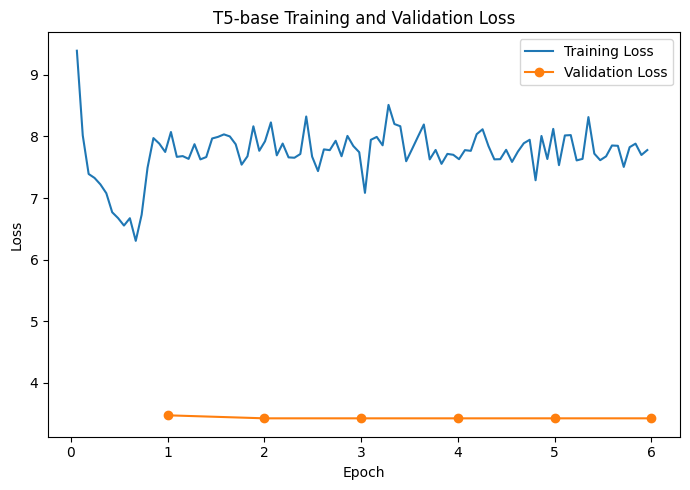

Saved plot to:
/content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_base_training_validation_loss.png


In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    train_loss_base["epoch"],
    train_loss_base["loss"],
    label="Training Loss")

plt.plot(
    val_loss_base["epoch"],
    val_loss_base["eval_loss"],
    marker="o",
    label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("T5-base Training and Validation Loss")
plt.legend()
plt.tight_layout()

plot_path = os.path.join(BASE_DIR,"t5_base_training_validation_loss.png")
plt.savefig(plot_path,dpi=300,bbox_inches="tight")
plt.show()
print("Saved plot to:")
print(plot_path)

generate validation predictions

In [73]:
# T5-base validation predictions

val_inputs_base = val_df["encoder_input"].tolist()
val_references_base = val_df["decoder_target"].tolist()

fine_tuned_model_base = trainer_base.model.to(DEVICE)

val_predictions_base = generate_predictions_batched(
    model=fine_tuned_model_base,
    tokenizer=ft_tokenizer_base,
    texts=val_inputs_base,
    batch_size=4,
)

print("Generated T5-base validation predictions:", len(val_predictions_base))
print("\nExample prediction:\n")
print(val_predictions_base[0])
print("\nReference:\n")
print(val_references_base[0])

Generated T5-base validation predictions: 516

Example prediction:

Live cattle futures ended the session with losses of 0.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500. Feeders were down 1.50

In [74]:
# T5-base validation evaluation
val_metrics_base, val_sts_scores_base = evaluate_predictions_full(
    predictions=val_predictions_base,
    references=val_references_base,
    model_label="t5-base-finetuned-validation",
)
display(pd.DataFrame([val_metrics_base]))

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine
0,t5-base-finetuned-validation,0.172862,0.048087,0.139755,1.709272,0.095008,0.84691,0.815189,0.830293,0.556216


In [75]:
# Save T5-base validation predictions

val_output_base_df = val_df.copy()

val_output_base_df["model"] = "t5-base-finetuned"
val_output_base_df["prediction"] = val_predictions_base
val_output_base_df["sts_sbert_cosine"] = val_sts_scores_base

val_base_path = os.path.join(BASE_DIR, "t5_base_validation_predictions.csv")

val_output_base_df.to_csv(val_base_path,index=False)

print("Saved T5-base validation predictions:", val_base_path)

Saved T5-base validation predictions: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_base_validation_predictions.csv


### Generate fine-tuned predictions in batches

In [72]:
fine_tuned_model_base = (trainer_base.model.to(DEVICE))

test_inputs = test_df["encoder_input"].tolist()
test_references = test_df["decoder_target"].tolist()
fine_tuned_pred_base = generate_predictions_batched(
    model=fine_tuned_model_base,
    tokenizer=ft_tokenizer_base,
    texts=test_inputs,
    batch_size=4,
)
print("Generated T5-base predictions:",len(fine_tuned_pred_base))

print("\nPrediction:\n")
print(fine_tuned_pred_base[0])
print("\nReference:\n")
print(test_references[0])

Generated T5-base predictions: 795

Prediction:

Live cattle futures ended the session with losses of 0.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500. Feeders were down 1.500 to 1.500. Feeders were down 1.500. Feeders were dow

In [77]:
fine_tuned_metrics_base, base_sts_scores = (evaluate_predictions_full(
        predictions=fine_tuned_pred_base,
        references=test_references,
        model_label="t5-base-finetuned",
    ))

display(pd.DataFrame([fine_tuned_metrics_base]))

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine
0,t5-base-finetuned,0.172248,0.050283,0.136975,1.43227,0.087548,0.849526,0.809959,0.829002,0.556284


In [78]:
t5_base_test_df = test_df.copy()

t5_base_test_df["model"] = "t5-base-finetuned"
t5_base_test_df["prediction"] = fine_tuned_pred_base
t5_base_test_df["sts_sbert_cosine"] = base_sts_scores

base_prediction_path = os.path.join(BASE_DIR,"t5_base_finetuned_test_predictions.csv",)

t5_base_test_df.to_csv(base_prediction_path,index=False,)

base_metrics_path = os.path.join(BASE_DIR,"t5_base_finetuned_metrics.csv",)

pd.DataFrame([fine_tuned_metrics_base]).to_csv(base_metrics_path,index=False,)

print("Saved predictions:", base_prediction_path)
print("Saved metrics:", base_metrics_path)

Saved predictions: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_base_finetuned_test_predictions.csv
Saved metrics: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_base_finetuned_metrics.csv


In [ ]:
# sts
fine_tuned_pred_base
fine_tuned_pred_base
"t5-base-finetuned"

### Post-hoc 5-fold stability analysis

In [80]:
K = 5
kf = KFold(n_splits=K,shuffle=True,random_state=SEED,)

fold_metrics = []

test_indices = np.arange(len(test_df))

for fold_num, (_, fold_idx) in enumerate(kf.split(test_indices),start=1,):

    # Select predictions and references that belong to this fold
    fold_preds = [fine_tuned_pred_base[i]for i in fold_idx]

    fold_refs = [test_references[i]for i in fold_idx]

    fold_metrics_row, _ = evaluate_predictions_full(
        predictions=fold_preds,
        references=fold_refs,
        model_label=f"t5-base-finetuned-fold{fold_num}",
    )
    fold_metrics_row["fold"] = fold_num
    fold_metrics_row["n_examples"] = len(fold_idx)
    fold_metrics.append(fold_metrics_row)


fold_metrics_df = pd.DataFrame(fold_metrics)

display(fold_metrics_df)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine,fold,n_examples
0,t5-base-finetuned-fold1,0.179901,0.054586,0.141468,1.494467,0.086607,0.852382,0.813034,0.831904,0.575991,1,159
1,t5-base-finetuned-fold2,0.168806,0.047033,0.133364,1.138821,0.084563,0.847861,0.807968,0.827214,0.551627,2,159
2,t5-base-finetuned-fold3,0.167717,0.048315,0.136689,1.588380,0.089712,0.846839,0.809565,0.827494,0.541077,3,159
3,t5-base-finetuned-fold4,0.172133,0.050718,0.137092,1.480269,0.087450,0.850782,0.809680,0.829489,0.555665,4,159
4,t5-base-finetuned-fold5,0.171627,0.050671,0.136753,1.452022,0.089406,0.849767,0.809546,0.828906,0.557061,5,159


In [81]:
metric_columns = [col for col in fold_metrics_df.columns if col not in ["model", "fold", "n_examples"]]

fold_aggregate_df = (fold_metrics_df[metric_columns].agg(["mean", "std"]).T.reset_index())

fold_aggregate_df.columns = ["metric","mean","std",]
display(fold_aggregate_df)

,metric,mean,std
0,rouge1,0.172037,0.004773
1,rouge2,0.050264,0.002885
2,rougeL,0.137073,0.002886
3,sacrebleu,1.430792,0.171051
4,meteor,0.087548,0.002118
5,bertscore_precision,0.849526,0.002224
6,bertscore_recall,0.809959,0.001859
7,bertscore_f1,0.829002,0.001880
8,sts_sbert_cosine,0.556284,0.012672


In [82]:
sts_ci_base = bootstrap_mean_ci(base_sts_scores)
print(sts_ci_base)

{'mean': 0.5562843084335327, 'ci_lower': 0.5451385974884033, 'ci_upper': 0.5669258832931519}


In [83]:
# ============================================================
# T5-base numeric support rate
# ============================================================
t5_base_test_df["numeric_support_rate"] = [numeric_support_rate(prediction=pred,
        source_text=source,)for pred, source in zip(t5_base_test_df["prediction"],
        t5_base_test_df["encoder_input"],)]

numeric_mean_base = (t5_base_test_df["numeric_support_rate"].dropna().mean())
print("T5-base mean numeric support rate:",numeric_mean_base)

print("Examples containing generated numbers:",t5_base_test_df["numeric_support_rate"].notna().sum())

T5-base mean numeric support rate: 0.3756572954565568
Examples containing generated numbers: 684


In [11]:
# ============================================================
# RECOVER SAVED EXPERIMENT RESULTS AFTER COLAB RESTART
# ============================================================
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/266/266_final_project"
print("BASE_DIR:", BASE_DIR)

BASE_DIR: /content/drive/MyDrive/Colab Notebooks/266/266_final_project


In [12]:
# List saved CSV files
csv_files = sorted([f for f in os.listdir(BASE_DIR)if f.endswith(".csv")])
print("Saved CSV files:\n")
for f in csv_files:
      print(f)

Saved CSV files:

T5_finetuned_combined_metrics.csv
T5_finetuned_combined_predictions.csv
model_metrics.csv
model_predictions.csv
t5_base_finetuned_metrics.csv
t5_base_finetuned_test_predictions.csv
t5_base_validation_predictions.csv
t5_small_5fold_stability_aggregate.csv
t5_small_5fold_stability_metrics.csv
t5_small_finetuned_metrics.csv
t5_small_finetuned_test_predictions.csv
t5_small_validation_predictions.csv


In [13]:
for f in csv_files:
    if ("fold" in f.lower()or "stability" in f.lower()):
        print(f)

t5_small_5fold_stability_aggregate.csv
t5_small_5fold_stability_metrics.csv


In [14]:
# ============================================================
# LOAD T5-SMALL RESULTS
# ============================================================
t5_small_test_df = pd.read_csv(os.path.join(BASE_DIR,"t5_small_finetuned_test_predictions.csv"))
t5_small_metrics_df = pd.read_csv(os.path.join(BASE_DIR,"t5_small_finetuned_metrics.csv"))
t5_small_val_df = pd.read_csv(os.path.join(BASE_DIR,"t5_small_validation_predictions.csv"))
t5_small_fold_metrics_df = pd.read_csv(os.path.join(BASE_DIR,"t5_small_5fold_stability_metrics.csv"))
t5_small_fold_aggregate_df = pd.read_csv(os.path.join(BASE_DIR,"t5_small_5fold_stability_aggregate.csv"))
print("T5-small files loaded.")

T5-small files loaded.


In [15]:
print("T5-SMALL FINAL TEST METRICS")
display(t5_small_metrics_df)

print("\nT5-SMALL TEST PREDICTIONS")
display(t5_small_test_df.head())

print("\nT5-SMALL 5-FOLD RESULTS")
display(t5_small_fold_metrics_df)

print("\nT5-SMALL 5-FOLD MEAN / STD")
display(t5_small_fold_aggregate_df)

T5-SMALL FINAL TEST METRICS


,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine
0,t5-small-finetuned,0.258826,0.086809,0.190723,5.489256,0.161707,0.875445,0.8374,0.855727,0.635853



T5-SMALL TEST PREDICTIONS


,source,market,date,instruction,table_data,report,prompts,encoder_input,decoder_target,market_summary,model,prediction,sts_sbert_cosine,numeric_support_rate
0,totalfarmmarketing,cattle,2022-10-25,Please act as an expert financial market analy...,Date P...,"Oct live cattle gained 0.075 to 151.675, closi...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"Oct live cattle gained 0.075 to 151.675, closi...",Product: Live Cattle Future (front month) (Oct...,t5-small-finetuned,"Oct live cattle slipped 0.300 to 142.250, and ...",0.792407,0.333333
1,totalfarmmarketing,cattle,2022-10-26,Please act as an expert financial market analy...,Date P...,Oct live cattle slipped .225 to 151.450 with e...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,Oct live cattle slipped .225 to 151.450 with e...,Product: Live Cattle Future (front month) (Oct...,t5-small-finetuned,"Cattle futures saw mixed trade on Tuesday, as ...",0.845670,0.300000
2,totalfarmmarketing,cattle,2022-10-27,Please act as an expert financial market analy...,Date P...,"The cattle market came under selling pressure,...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"The cattle market came under selling pressure,...",Product: Live Cattle Future (front month) (Oct...,t5-small-finetuned,"Oct live cattle slipped 0.600 to 142.250, and ...",0.816529,0.250000
3,totalfarmmarketing,cattle,2022-10-28,Please act as an expert financial market analy...,Date P...,"The cattle market was choppy on Friday, finish...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"The cattle market was choppy on Friday, finish...",Product: Live Cattle Future (front month) (Oct...,t5-small-finetuned,"Cattle futures saw mixed trade on Tuesday, as ...",0.799175,0.433333
4,totalfarmmarketing,cattle,2022-10-31,Please act as an expert financial market analy...,Date Pr...,October live cattle went off the board today a...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,October live cattle went off the board today a...,Product: Live Cattle Future (front month) (Dec...,t5-small-finetuned,Cattle futures saw mixed trade to start the we...,0.800510,0.333333



T5-SMALL 5-FOLD RESULTS


,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine,fold,n_examples
0,t5-small-finetuned-fold1,0.277876,0.096550,0.202562,6.293273,0.171575,0.878992,0.840469,0.859037,0.657810,1,159
1,t5-small-finetuned-fold2,0.257201,0.089146,0.190437,5.300662,0.163747,0.875666,0.836586,0.855402,0.631220,2,159
2,t5-small-finetuned-fold3,0.253741,0.081379,0.186662,5.279566,0.162492,0.871538,0.835276,0.852766,0.606644,3,159
3,t5-small-finetuned-fold4,0.251101,0.082582,0.187261,5.240479,0.149342,0.874044,0.836429,0.854540,0.628514,4,159
4,t5-small-finetuned-fold5,0.254083,0.084608,0.186469,5.250250,0.161381,0.876987,0.838239,0.856888,0.655076,5,159



T5-SMALL 5-FOLD MEAN / STD


,metric,mean,std
0,rouge1,0.258800,0.010881
1,rouge2,0.086853,0.006175
2,rougeL,0.190678,0.006834
3,sacrebleu,5.472846,0.459252
4,meteor,0.161707,0.007987
5,bertscore_precision,0.875445,0.002839
6,bertscore_recall,0.837400,0.002015
7,bertscore_f1,0.855727,0.002376
8,sts_sbert_cosine,0.635853,0.021095


In [16]:
# ============================================================
# LOAD T5-BASE RESULTS
# ============================================================
t5_base_test_df = pd.read_csv(os.path.join(BASE_DIR,"t5_base_finetuned_test_predictions.csv"))
t5_base_metrics_df = pd.read_csv(os.path.join(BASE_DIR,"t5_base_finetuned_metrics.csv"))
t5_base_val_df = pd.read_csv(os.path.join(BASE_DIR,"t5_base_validation_predictions.csv"))
print("T5-base files loaded.")

T5-base files loaded.


In [17]:
print("T5-BASE FINAL TEST METRICS")
display(t5_base_metrics_df)

print("\nT5-BASE TEST PREDICTIONS")
display(t5_base_test_df.head())

print("\nT5-BASE VALIDATION PREDICTIONS")
display(t5_base_val_df.head())

T5-BASE FINAL TEST METRICS


,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine
0,t5-base-finetuned,0.172248,0.050283,0.136975,1.43227,0.087548,0.849526,0.809959,0.829002,0.556284



T5-BASE TEST PREDICTIONS


,source,market,date,instruction,table_data,report,prompts,encoder_input,decoder_target,market_summary,model,prediction,sts_sbert_cosine
0,totalfarmmarketing,cattle,2022-10-25,Please act as an expert financial market analy...,Date P...,"Oct live cattle gained 0.075 to 151.675, closi...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"Oct live cattle gained 0.075 to 151.675, closi...",Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.446966
1,totalfarmmarketing,cattle,2022-10-26,Please act as an expert financial market analy...,Date P...,Oct live cattle slipped .225 to 151.450 with e...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,Oct live cattle slipped .225 to 151.450 with e...,Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.510061
2,totalfarmmarketing,cattle,2022-10-27,Please act as an expert financial market analy...,Date P...,"The cattle market came under selling pressure,...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"The cattle market came under selling pressure,...",Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.495101
3,totalfarmmarketing,cattle,2022-10-28,Please act as an expert financial market analy...,Date P...,"The cattle market was choppy on Friday, finish...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"The cattle market was choppy on Friday, finish...",Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.651169
4,totalfarmmarketing,cattle,2022-10-31,Please act as an expert financial market analy...,Date Pr...,October live cattle went off the board today a...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,October live cattle went off the board today a...,Product: Live Cattle Future (front month) (Dec...,t5-base-finetuned,Live cattle futures ended the session with los...,0.478938



T5-BASE VALIDATION PREDICTIONS


,source,market,date,instruction,table_data,report,prompts,encoder_input,decoder_target,input_length,target_length,raw_table_rows,market_summary,model,prediction,sts_sbert_cosine
0,totalfarmmarketing,cattle,2022-09-15,Please act as an expert financial market analy...,Date P...,Live cattle futures found some buying strength...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,Live cattle futures found some buying strength...,3061,304,111,Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.507869
1,totalfarmmarketing,cattle,2022-09-16,Please act as an expert financial market analy...,Date P...,Live cattle futures traded slightly lower on s...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,Live cattle futures traded slightly lower on s...,3042,439,111,Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.486807
2,totalfarmmarketing,cattle,2022-09-19,Please act as an expert financial market analy...,Date P...,Oct cattle gained .225 to 145.725 and Dec catt...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,Oct cattle gained .225 to 145.725 and Dec catt...,2761,289,101,Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.499885
3,totalfarmmarketing,cattle,2022-09-20,Please act as an expert financial market analy...,Date P...,Live cattle futures were mixed as the cash mar...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,Live cattle futures were mixed as the cash mar...,2891,395,106,Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.511488
4,totalfarmmarketing,cattle,2022-09-21,Please act as an expert financial market analy...,Date P...,The feeder cattle markets saw additional techn...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,The feeder cattle markets saw additional techn...,3025,347,111,Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.519937


In [18]:
print("T5-small columns:")
print(t5_small_test_df.columns.tolist())

print("\nT5-base columns:")
print(t5_base_test_df.columns.tolist())

T5-small columns:
['source', 'market', 'date', 'instruction', 'table_data', 'report', 'prompts', 'encoder_input', 'decoder_target', 'market_summary', 'model', 'prediction', 'sts_sbert_cosine', 'numeric_support_rate']

T5-base columns:
['source', 'market', 'date', 'instruction', 'table_data', 'report', 'prompts', 'encoder_input', 'decoder_target', 'market_summary', 'model', 'prediction', 'sts_sbert_cosine']


In [19]:
# ============================================================
# COMBINE FINE-TUNED MODEL METRICS
# ============================================================
finetuned_metrics_df = pd.concat([t5_small_metrics_df,t5_base_metrics_df,],ignore_index=True)
display(finetuned_metrics_df)

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine
0,t5-small-finetuned,0.258826,0.086809,0.190723,5.489256,0.161707,0.875445,0.837400,0.855727,0.635853
1,t5-base-finetuned,0.172248,0.050283,0.136975,1.432270,0.087548,0.849526,0.809959,0.829002,0.556284


In [20]:
finetuned_metrics_df.to_csv(os.path.join(BASE_DIR,"T5_finetuned_combined_metrics.csv"),index=False)
print("Combined fine-tuned metrics saved.")

Combined fine-tuned metrics saved.


In [21]:
finetuned_predictions_df = pd.concat([t5_small_test_df,t5_base_test_df,],ignore_index=True)
print(finetuned_predictions_df["model"].value_counts())
display(finetuned_predictions_df.head())

model
t5-small-finetuned    795
t5-base-finetuned     795
Name: count, dtype: int64


,source,market,date,instruction,table_data,report,prompts,encoder_input,decoder_target,market_summary,model,prediction,sts_sbert_cosine,numeric_support_rate
0,totalfarmmarketing,cattle,2022-10-25,Please act as an expert financial market analy...,Date P...,"Oct live cattle gained 0.075 to 151.675, closi...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"Oct live cattle gained 0.075 to 151.675, closi...",Product: Live Cattle Future (front month) (Oct...,t5-small-finetuned,"Oct live cattle slipped 0.300 to 142.250, and ...",0.792407,0.333333
1,totalfarmmarketing,cattle,2022-10-26,Please act as an expert financial market analy...,Date P...,Oct live cattle slipped .225 to 151.450 with e...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,Oct live cattle slipped .225 to 151.450 with e...,Product: Live Cattle Future (front month) (Oct...,t5-small-finetuned,"Cattle futures saw mixed trade on Tuesday, as ...",0.845670,0.300000
2,totalfarmmarketing,cattle,2022-10-27,Please act as an expert financial market analy...,Date P...,"The cattle market came under selling pressure,...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"The cattle market came under selling pressure,...",Product: Live Cattle Future (front month) (Oct...,t5-small-finetuned,"Oct live cattle slipped 0.600 to 142.250, and ...",0.816529,0.250000
3,totalfarmmarketing,cattle,2022-10-28,Please act as an expert financial market analy...,Date P...,"The cattle market was choppy on Friday, finish...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"The cattle market was choppy on Friday, finish...",Product: Live Cattle Future (front month) (Oct...,t5-small-finetuned,"Cattle futures saw mixed trade on Tuesday, as ...",0.799175,0.433333
4,totalfarmmarketing,cattle,2022-10-31,Please act as an expert financial market analy...,Date Pr...,October live cattle went off the board today a...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,October live cattle went off the board today a...,Product: Live Cattle Future (front month) (Dec...,t5-small-finetuned,Cattle futures saw mixed trade to start the we...,0.800510,0.333333


In [22]:
finetuned_predictions_df.to_csv(os.path.join(BASE_DIR,"T5_finetuned_combined_predictions.csv"),index=False)
print("Combined fine-tuned predictions saved.")

Combined fine-tuned predictions saved.


In [23]:
predictions_df = pd.read_csv(os.path.join(BASE_DIR,"model_predictions.csv"))
print(predictions_df["model"].value_counts())
display(predictions_df.head())

model
t5-small-zero-shot    795
t5-small-finetuned    795
t5-base-zero-shot     795
t5-base-finetuned     795
Name: count, dtype: int64


,model,encoder_input,decoder_target,prediction
0,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,"Oct live cattle gained 0.075 to 151.675, closi...",: 36.77 Percentage price change: 25.63% Daily ...
1,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,Oct live cattle slipped .225 to 151.450 with e...,": 37.77 Percentage price change: 26,32% Daily ..."
2,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,"The cattle market came under selling pressure,...",: 142.72 Absolute price change: 36.88 Percenta...
3,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,"The cattle market was choppy on Friday, finish...",": 37.33 Percentage price change: 26,10% Daily ..."
4,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,October live cattle went off the board today a...,: 179.45 Period high: 182.38 Period low: 146.7...


In [24]:
# ============================================================
# EXPERIMENT RECOVERY SUMMARY
# ============================================================
files_to_check = [
    "t5_small_validation_predictions.csv",
    "t5_small_finetuned_test_predictions.csv",
    "t5_small_finetuned_metrics.csv",
    "t5_small_5fold_stability_metrics.csv",
    "t5_small_5fold_stability_aggregate.csv",
    "t5_base_validation_predictions.csv",
    "t5_base_finetuned_test_predictions.csv",
    "t5_base_finetuned_metrics.csv",
    "model_metrics.csv",
    "model_predictions.csv",]

recovery_rows = []
for filename in files_to_check:
    path = os.path.join(BASE_DIR,filename)
    recovery_rows.append({"file": filename,"exists": os.path.exists(path),})

recovery_df = pd.DataFrame(recovery_rows)
display(recovery_df)

,file,exists
0,t5_small_validation_predictions.csv,True
1,t5_small_finetuned_test_predictions.csv,True
2,t5_small_finetuned_metrics.csv,True
3,t5_small_5fold_stability_metrics.csv,True
4,t5_small_5fold_stability_aggregate.csv,True
5,t5_base_validation_predictions.csv,True
6,t5_base_finetuned_test_predictions.csv,True
7,t5_base_finetuned_metrics.csv,True
8,model_metrics.csv,True
9,model_predictions.csv,True


In [25]:
# ============================================================
# REBUILD T5-BASE 5-FOLD STABILITY FROM SAVED PREDICTIONS
# ============================================================
from sklearn.model_selection import KFold

# Load saved T5-base predictions
t5_base_test_df = pd.read_csv(os.path.join(BASE_DIR,"t5_base_finetuned_test_predictions.csv"))

print(t5_base_test_df.columns.tolist())
print("Rows:", len(t5_base_test_df))
display(t5_base_test_df.head())

['source', 'market', 'date', 'instruction', 'table_data', 'report', 'prompts', 'encoder_input', 'decoder_target', 'market_summary', 'model', 'prediction', 'sts_sbert_cosine']
Rows: 795


,source,market,date,instruction,table_data,report,prompts,encoder_input,decoder_target,market_summary,model,prediction,sts_sbert_cosine
0,totalfarmmarketing,cattle,2022-10-25,Please act as an expert financial market analy...,Date P...,"Oct live cattle gained 0.075 to 151.675, closi...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"Oct live cattle gained 0.075 to 151.675, closi...",Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.446966
1,totalfarmmarketing,cattle,2022-10-26,Please act as an expert financial market analy...,Date P...,Oct live cattle slipped .225 to 151.450 with e...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,Oct live cattle slipped .225 to 151.450 with e...,Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.510061
2,totalfarmmarketing,cattle,2022-10-27,Please act as an expert financial market analy...,Date P...,"The cattle market came under selling pressure,...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"The cattle market came under selling pressure,...",Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.495101
3,totalfarmmarketing,cattle,2022-10-28,Please act as an expert financial market analy...,Date P...,"The cattle market was choppy on Friday, finish...",{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,"The cattle market was choppy on Friday, finish...",Product: Live Cattle Future (front month) (Oct...,t5-base-finetuned,Live cattle futures ended the session with los...,0.651169
4,totalfarmmarketing,cattle,2022-10-31,Please act as an expert financial market analy...,Date Pr...,October live cattle went off the board today a...,{'instruction': 'Please act as an expert finan...,Generate a financial market report.\n\nInstruc...,October live cattle went off the board today a...,Product: Live Cattle Future (front month) (Dec...,t5-base-finetuned,Live cattle futures ended the session with los...,0.478938


In [33]:
K = 5
kf = KFold(n_splits=K,shuffle=True,random_state=SEED,)

fold_metrics_base = []
indices = np.arange(len(t5_base_test_df))

for fold_num, (_, fold_idx) in enumerate(kf.split(indices),start=1,):

    fold_preds = (t5_base_test_df.iloc[fold_idx]["prediction"].tolist())

    fold_refs = (t5_base_test_df.iloc[fold_idx]["decoder_target"].tolist())

    fold_metrics_row, _ = evaluate_predictions_full(predictions=fold_preds,references=fold_refs,
        model_label=f"t5-base-finetuned-fold{fold_num}",)

    fold_metrics_row["fold"] = fold_num
    fold_metrics_row["n_examples"] = len(fold_idx)
    fold_metrics_base.append(fold_metrics_row)

fold_metrics_base_df = pd.DataFrame(fold_metrics_base)
display(fold_metrics_base_df)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1,sts_sbert_cosine,fold,n_examples
0,t5-base-finetuned-fold1,0.179901,0.054586,0.141468,1.494467,0.086607,0.852382,0.813034,0.831904,0.575991,1,159
1,t5-base-finetuned-fold2,0.168806,0.047033,0.133364,1.138821,0.084563,0.847861,0.807968,0.827214,0.551627,2,159
2,t5-base-finetuned-fold3,0.167717,0.048315,0.136689,1.588380,0.089712,0.846839,0.809565,0.827494,0.541077,3,159
3,t5-base-finetuned-fold4,0.172133,0.050718,0.137092,1.480269,0.087450,0.850782,0.809680,0.829489,0.555665,4,159
4,t5-base-finetuned-fold5,0.171627,0.050671,0.136753,1.452022,0.089406,0.849767,0.809546,0.828906,0.557061,5,159


In [34]:
metric_columns_base = [col for col in fold_metrics_base_df.columns
                       if col not in ["model","fold","n_examples",]]

fold_aggregate_base_df = (fold_metrics_base_df[metric_columns_base].agg(["mean", "std"]).T.reset_index())

fold_aggregate_base_df.columns = ["metric","mean","std",]
display(fold_aggregate_base_df)

,metric,mean,std
0,rouge1,0.172037,0.004773
1,rouge2,0.050264,0.002885
2,rougeL,0.137073,0.002886
3,sacrebleu,1.430792,0.171051
4,meteor,0.087548,0.002118
5,bertscore_precision,0.849526,0.002224
6,bertscore_recall,0.809959,0.001859
7,bertscore_f1,0.829002,0.001880
8,sts_sbert_cosine,0.556284,0.012672


In [35]:
base_fold_metrics_path = os.path.join(BASE_DIR,"t5_base_5fold_stability_metrics.csv")

base_fold_aggregate_path = os.path.join(BASE_DIR,"t5_base_5fold_stability_aggregate.csv")

fold_metrics_base_df.to_csv(base_fold_metrics_path,index=False)

fold_aggregate_base_df.to_csv(base_fold_aggregate_path,index=False)

print("Saved:", base_fold_metrics_path)
print("Saved:", base_fold_aggregate_path)

Saved: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_base_5fold_stability_metrics.csv
Saved: /content/drive/MyDrive/Colab Notebooks/266/266_final_project/t5_base_5fold_stability_aggregate.csv


In [36]:
metrics_df = pd.read_csv(os.path.join(BASE_DIR,"model_metrics.csv"))

predictions_df = pd.read_csv(os.path.join(BASE_DIR,"model_predictions.csv"))

print("ALL MODEL METRICS")
display(metrics_df)

print("\nPrediction counts by model")
display(predictions_df["model"].value_counts().reset_index())

print("\nSample predictions")
display(predictions_df.head())

ALL MODEL METRICS


,model,rouge1,rouge2,rougeL,sacrebleu,meteor,bertscore_precision,bertscore_recall,bertscore_f1
0,t5-small-zero-shot,0.057857,0.001057,0.040656,0.004020,0.026264,0.771497,0.780427,0.775841
1,t5-small-finetuned,0.272943,0.096536,0.203133,6.403039,0.177760,0.876687,0.840908,0.858156
2,t5-base-zero-shot,0.057949,0.003745,0.040108,0.224147,0.032917,0.752887,0.777490,0.764631
3,t5-base-zero-shot,0.057949,0.003745,0.040108,0.224147,0.032917,0.752887,0.777490,0.764631
4,t5-base-finetuned,0.286315,0.108871,0.213307,7.417643,0.194107,0.876012,0.846746,0.860887



Prediction counts by model


,model,count
0,t5-small-zero-shot,795
1,t5-small-finetuned,795
2,t5-base-zero-shot,795
3,t5-base-finetuned,795



Sample predictions


,model,encoder_input,decoder_target,prediction
0,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,"Oct live cattle gained 0.075 to 151.675, closi...",: 36.77 Percentage price change: 25.63% Daily ...
1,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,Oct live cattle slipped .225 to 151.450 with e...,": 37.77 Percentage price change: 26,32% Daily ..."
2,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,"The cattle market came under selling pressure,...",: 142.72 Absolute price change: 36.88 Percenta...
3,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,"The cattle market was choppy on Friday, finish...",": 37.33 Percentage price change: 26,10% Daily ..."
4,t5-small-zero-shot,Generate a financial market report.\n\nInstruc...,October live cattle went off the board today a...,: 179.45 Period high: 182.38 Period low: 146.7...


### Evaluate and append fine-tuned results

In [ ]:
# Free memory
del ft_model_base, trainer
torch.cuda.empty_cache() if torch.cuda.is_available() else None

### Evaluation
- Output commentary Vs. Reference commentary
- Output commentary vs. Underlying numerical facts

- Evaluation Metrics
  - Lexical
  - ROUGE
  - BLEU

- Semantic
  - BERTScore

- Factual grounding
  - LLM as a judge

## LLM as a Judge
judge factual grounding + overall commentary quality


## Run judge over predictions

In [93]:
from openai import OpenAI
from tqdm import tqdm

In [98]:
api_key = os.environ.get("OPENAI_API_KEY") or os.environ.get("OPENAI_API")
if not api_key:
    raise RuntimeError(
        "No OpenAI key found. Set OPENAI_API_KEY (or OPENAI_API) as an "
        "environment variable or in a .env file before running this script."
    )

client = OpenAI(api_key=api_key)

print("=" * 60)
print(f"CONFIRMED MODEL BEING USED: {LLM_MODEL}")
print("=" * 60)

CONFIRMED MODEL BEING USED: gpt-4o-mini


In [111]:
# LLM-as-a-judge evaluation

SMALL_PATH = os.path.join(BASE_DIR, "t5_small_finetuned_test_predictions.csv")
BASE_PATH  = os.path.join(BASE_DIR, "t5_base_finetuned_test_predictions.csv")

import os
import random
import time

import numpy as np
import pandas as pd
from openai import OpenAI
from tqdm import tqdm

LLM_MODEL = "gpt-4o-mini"

RANDOM_SEED = 42
LLM_JUDGE_SAMPLE_SIZE = 50
OUTPUT_PATH = "llm_judge_results.txt"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError(
        "No OpenAI key found. In a cell above this one, run:\n"
        "  import os\n"
        "  os.environ['OPENAI_API_KEY'] = 'sk-...'   # Sid's key\n"
        "then re-run this cell."
    )

client = OpenAI(api_key=api_key)

print("=" * 60)
print(f"CONFIRMED MODEL BEING USED: {LLM_MODEL}")
print("=" * 60)


def call_with_retry(fn, max_retries=5):
    for attempt in range(max_retries):
        try:
            return fn()
        except Exception as e:
            msg = str(e).lower()
            if "rate" in msg or "429" in msg:
                wait = 2 ** attempt
                print(f"  [rate limit] backing off {wait}s...")
                time.sleep(wait)
            else:
                raise
    raise RuntimeError("Max retries exceeded")


def load_predictions(path):
    df = pd.read_csv(path)
    required = {"market", "date", "decoder_target", "prediction"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {missing}")
    return df


def llm_judge_quality(reference, prediction):
    prompt = f"""You are an expert financial-news evaluator.
Given the reference (ground-truth) market report and a model-generated market report,
rate the holistic quality of the model-generated report on a scale of 1 to 10.
Consider fluency, structural coherence, and factual alignment with the reference.
Output ONLY the integer score.

Reference Report: {reference}
Model Report: {prediction}
"""
    try:
        response = call_with_retry(lambda: client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
        ))
        return float(response.choices[0].message.content.strip())
    except Exception as e:
        print(f"  [warn] judge call failed: {e}")
        return None


def compute_decoder_sts(prediction, reference):
    prompt = f"""Evaluate the Semantic Textual Similarity (STS) between the following two sentences.
Score them on a scale from 1 (completely dissimilar) to 5 (exact same meaning).
Output ONLY the float number.

Sentence 1: {reference}
Sentence 2: {prediction}
"""
    try:
        response = call_with_retry(lambda: client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
        ))
        score_str = response.choices[0].message.content.strip()
        return (float(score_str) - 1) / 4.0
    except Exception as e:
        print(f"  [warn] decoder STS call failed: {e}")
        return None


def mean_std(values):
    values = [v for v in values if v is not None]
    if not values:
        return 0.0, 0.0
    return float(np.mean(values)), float(np.std(values))


def evaluate_model(df, model_label, lines):
    lines.append("=" * 70)
    lines.append(f"LLM-AS-A-JUDGE + DECODER STS: {model_label}")
    lines.append("=" * 70)
    lines.append(f"Judge model: {LLM_MODEL}")
    lines.append(f"Total examples available: {len(df)}")

    sample_size = min(LLM_JUDGE_SAMPLE_SIZE, len(df))
    sample_idx = random.sample(range(len(df)), sample_size)

    judge_scores, sts_scores, per_example = [], [], []
    for i in tqdm(sample_idx, desc=f"{model_label} judge+STS"):
        row = df.iloc[i]
        ref, pred = row["decoder_target"], row["prediction"]
        j = llm_judge_quality(ref, pred)
        s = compute_decoder_sts(pred, ref)
        judge_scores.append(j)
        sts_scores.append(s)
        per_example.append((row["market"], row["date"], j, s))

    judge_mean, judge_std = mean_std(judge_scores)
    sts_mean, sts_std = mean_std(sts_scores)

    lines.append(f"LLM-judge quality (n={sample_size}, scale 1-10): {judge_mean:.2f} +/- {judge_std:.2f}")
    lines.append(f"Decoder STS, LLM-based (n={sample_size}, scale 0-1): {sts_mean:.4f} +/- {sts_std:.4f}")
    lines.append("")
    lines.append("Per-example scores (market, date, judge_score, decoder_sts):")
    for market, date, j, s in per_example:
        j_str = f"{j:.1f}" if j is not None else "N/A"
        s_str = f"{s:.3f}" if s is not None else "N/A"
        lines.append(f"  {market:20s} {date:12s} judge={j_str:6s} sts={s_str}")
    lines.append("")

    return {
        "model": model_label,
        "n_samples": sample_size,
        "llm_judge_mean": judge_mean,
        "llm_judge_std": judge_std,
        "decoder_sts_mean": sts_mean,
        "decoder_sts_std": sts_std,
    }
# RUN
# ============================================================
lines = ["DataTales LLM-as-a-Judge Evaluation: T5-small vs T5-base", f"Judge model: {LLM_MODEL}", ""]
summary_rows = []

small_df = load_predictions(SMALL_PATH)
summary_rows.append(evaluate_model(small_df, "t5-small-finetuned", lines))

base_df = load_predictions(BASE_PATH)
summary_rows.append(evaluate_model(base_df, "t5-base-finetuned", lines))

lines.append("=" * 70)
lines.append("SUMMARY")
lines.append("=" * 70)
for row in summary_rows:
    lines.append(
        f"{row['model']:25s} judge={row['llm_judge_mean']:.2f}+/-{row['llm_judge_std']:.2f}  "
        f"decoder_sts={row['decoder_sts_mean']:.4f}+/-{row['decoder_sts_std']:.4f}"
    )

report = "\n".join(lines)
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    f.write(report)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("llm_judge_summary.csv", index=False)

print(report)
print(f"\nWrote full results to {OUTPUT_PATH}")
print(f"Wrote summary table to llm_judge_summary.csv")
display(summary_df)

CONFIRMED MODEL BEING USED: gpt-4o-mini


t5-base-finetuned judge+STS: 100%|██████████| 50/50 [00:49<00:00,  1.00it/s]

DataTales LLM-as-a-Judge Evaluation: T5-small vs T5-base
Judge model: gpt-4o-mini

LLM-AS-A-JUDGE + DECODER STS: t5-small-finetuned
Judge model: gpt-4o-mini
Total examples available: 795
LLM-judge quality (n=50, scale 1-10): 2.72 +/- 0.80
Decoder STS, LLM-based (n=50, scale 0-1): 0.1300 +/- 0.1322

Per-example scores (market, date, judge_score, decoder_sts):
  soybean              2022-09-28   judge=3.0    sts=0.250
  corn                 2022-11-14   judge=3.0    sts=0.000
  cattle               2022-12-01   judge=4.0    sts=0.375
  wheat                2022-09-28   judge=2.0    sts=0.250
  equity market        2022-07-18   judge=4.0    sts=0.125
  dairy                2022-12-02   judge=2.0    sts=0.000
  dairy                2022-10-31   judge=2.0    sts=0.000
  currency             2022-08-25   judge=3.0    sts=0.250
  wheat                2022-09-21   judge=2.0    sts=0.000
  corn                 2022-10-31   judge=4.0    sts=0.000
  treasury             2022-06-13   judge=2.0    

,model,n_samples,llm_judge_mean,llm_judge_std,decoder_sts_mean,decoder_sts_std
0,t5-small-finetuned,50,2.72,0.800999,0.130,0.132193
1,t5-base-finetuned,50,1.72,0.722219,0.035,0.086747


In [112]:
import shutil, os
shutil.copy("llm_judge_summary.csv", os.path.join(BASE_DIR, "llm_judge_summary.csv"))
shutil.copy("llm_judge_results.txt", os.path.join(BASE_DIR, "llm_judge_results.txt"))
print("Copied to Drive.")

Copied to Drive.
